2026-06-06 20:06:55.594691: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780776415.782808      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780776415.837619      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780776416.298846      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780776416.298885      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780776416.298887      57 computation_placer.cc:177] computation placer alr

Data Loaded ✅

Binary Distribution:
Label
0    14272
1     2046
Name: count, dtype: int64


/tmp/ipykernel_57/2105639834.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), 5000), random_state=42))



Top Features:
['SrcBytes', 'Heart_rate', 'TotBytes', 'Temp', 'Pulse_Rate', 'SpO2', 'Packet_num', 'Sport', 'SrcJitter', 'Rate', 'SIntPkt', 'DstLoad', 'Dur', 'Load', 'DstJitter', 'SrcLoad', 'DIntPkt', 'Flgs', 'SrcMac', 'Attack_Category']

Training Models...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-06-06 20:07:18.433524: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7828 - loss: 0.4731 - val_accuracy: 1.0000 - val_loss: 0.0131
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9978 - loss: 0.0164 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9993 - loss: 0.0047 - val_accuracy: 1.0000 - val_loss: 3.6184e-04
Epoch 4/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 1.7659e-04
Epoch 5/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 7.3062e-04 - val_accuracy: 1.0000 - val_loss: 1.0033e-04
Epoch 6/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9999 - loss: 8.1792e-04 - val_accuracy: 1.0000 - val_loss: 6.8223e-05
Epoch 7/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9998 - loss: 0.0028 - val_accuracy: 1.0000 - val_loss: 6.3259e-05
Epoch 8/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 6.1401e-04 - 

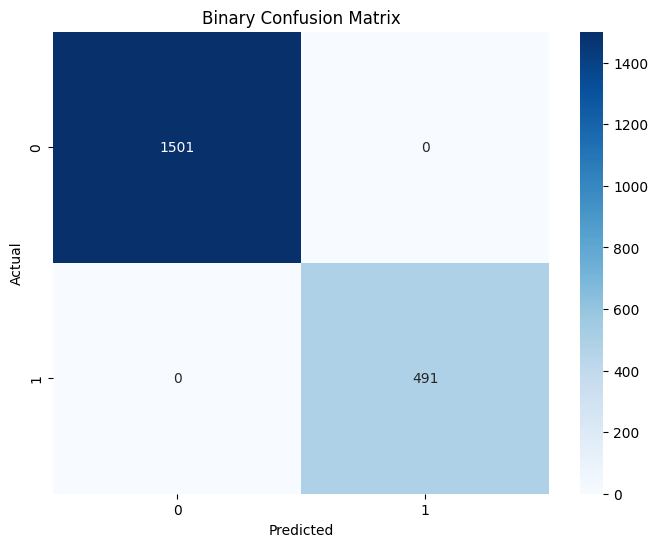


 ZERO-DAY RESULTS
Total Samples: 409
Detected Attacks: 409
Detection Rate: 100.00%

Cross Validation Mean: 1.0

Model Saved 

Sample Prediction: 0
Actual: 0


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, IsolationForest
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


df = pd.read_csv("/kaggle/input/datasets/shahdsameh123/binary11/wustl-ehms-2020_with_attacks_categories (5).csv")

print("Data Loaded ✅")


df = df.dropna()
df.columns = df.columns.str.replace(' ', '_')

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))


target_col = "Label"
df[target_col] = df[target_col].apply(lambda x: 0 if x == 0 else 1)

print("\nBinary Distribution:")
print(df[target_col].value_counts())


df_balanced = (
    df.groupby(target_col, group_keys=False)
      .apply(lambda x: x.sample(n=min(len(x), 5000), random_state=42))
      .reset_index(drop=True)
)


attack_df = df_balanced[df_balanced[target_col] == 1]

zero_size = int(len(attack_df) * 0.2)

df_zero = attack_df.sample(n=zero_size, random_state=42)
df_known = df_balanced.drop(df_zero.index)


X = df_known.drop(columns=[target_col])
y = df_known[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


selector = RandomForestClassifier(n_estimators=100, random_state=42)
selector.fit(X_train, y_train)

importances = selector.feature_importances_
top_idx = np.argsort(importances)[-20:]
top_features = X.columns[top_idx]

X_train = X_train[top_features]
X_test = X_test[top_features]
X_zero = df_zero.drop(columns=[target_col])[top_features]

print("\nTop Features:")
print(list(top_features))


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_zero_scaled = scaler.transform(X_zero)


rf = RandomForestClassifier(n_estimators=300, max_depth=25, random_state=42)

xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=8,
    eval_metric='logloss',
    random_state=42
)

lgbm = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    verbose=-1
)


dl_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

dl_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(patience=3, restore_best_weights=True)


print("\nTraining Models...")

rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)
lgbm.fit(X_train, y_train)

dl_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)


rf_pred = rf.predict(X_test)
xgb_pred = xgb.predict(X_test)
lgbm_pred = lgbm.predict(X_test)

dl_pred = (dl_model.predict(X_test_scaled) > 0.5).astype(int).reshape(-1)


vote = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb), ('lgbm', lgbm)],
    voting='soft'
)

vote.fit(X_train, y_train)
vote_pred = vote.predict(X_test)


results = {
    "RF": accuracy_score(y_test, rf_pred),
    "XGB": accuracy_score(y_test, xgb_pred),
    "LGBM": accuracy_score(y_test, lgbm_pred),
    "DL": accuracy_score(y_test, dl_pred),
    "Voting": accuracy_score(y_test, vote_pred)
}

print("\n========== RESULTS ==========")

for k, v in results.items():
    print(f"{k}: {v:.4f}")

best_model = max(results, key=results.get)
print("\nBest Model:", best_model)


final_pred = vote_pred

print("\nClassification Report:")
print(classification_report(y_test, final_pred))

cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Binary Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


iso = IsolationForest(
    contamination=0.2,
    n_estimators=300,
    random_state=42
)

iso.fit(X_train_scaled)

vote_zero_pred = vote.predict(X_zero)
iso_pred = iso.predict(X_zero_scaled)

final_zero_pred = []

for v, i in zip(vote_zero_pred, iso_pred):
    if i == -1:
        final_zero_pred.append(1)
    else:
        final_zero_pred.append(v)

final_zero_pred = np.array(final_zero_pred)

detected = (final_zero_pred == 1).sum()
total = len(final_zero_pred)

print("\n" + "="*40)
print(" ZERO-DAY RESULTS")
print("="*40)

print(f"Total Samples: {total}")
print(f"Detected Attacks: {detected}")
print(f"Detection Rate: {(detected/total)*100:.2f}%")


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(rf, X_train, y_train, cv=cv)

print("\nCross Validation Mean:", scores.mean())


joblib.dump(vote, "FINAL_BINARY_ZERO_MODEL.pkl")

print("\nModel Saved ")


sample = X_test.iloc[0:1]

pred = vote.predict(sample)

print("\nSample Prediction:", pred[0])
print("Actual:", y_test.iloc[0])